In [303]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from statsmodels.tsa.stattools import adfuller


In [356]:
Level_df1 = pd.read_csv('Level_VIX_TermSpread_2-10Spread_VXN.csv', index_col = ['Date'], parse_dates=True)
Level_df2 = pd.read_csv('Level_BKK_CFNAI_EquityVol_StLSI.csv', index_col = ['Date'], parse_dates=True)
Quarterly_df = pd.read_csv('Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv', index_col = ['Date'], parse_dates=True, date_format='%Y%Q')
First_Diff_df = pd.read_csv('First_Diff_UMich_UnemploymentRate.csv', index_col=['Date'], parse_dates=True)
MOVE_CESIUSD = pd.read_csv('MOVE_CESIUSD.csv', index_col=['Date'], parse_dates=True)
GPU = pd.read_csv('Geopolitical Risk 1985-2025.csv', index_col=['month'], parse_dates=True)
GEP = pd.read_csv('Global Economic Policy Uncertainty Data.csv', index_col = ['Date'], parse_dates = True)
NewOrders = pd.read_csv('New Orders.csv', index_col = [0], parse_dates=True)


## Compiling a Monthly Dataframe

In [357]:
# GEP, GPU, New Orders
Risk = GPU['2004-12-01':].iloc[:,0]
Uncertainty = GEP['2004-12-01':].iloc[:,0]

#Add in New Orders, UMich, Term Spread and Unemployment Rate
Risk_Uncertainty_New_Orders = pd.concat([Risk, Uncertainty, NewOrders], axis = 1)
Risk_Uncertainty_New_Orders = (Risk_Uncertainty_New_Orders.diff() / Risk_Uncertainty_New_Orders) * 100
Risk_Uncertainty_New_Orders = pd.concat([Risk_Uncertainty_New_Orders, First_Diff_df], axis = 1)
Risk_Uncertainty_New_Orders = Risk_Uncertainty_New_Orders.dropna(how = 'all')
Risk_Uncertainty_New_Orders.to_csv('PercentDifferenced_Risk_Uncertainty_New_Orders_UMich_Unemployment.csv')

In [358]:
# Combine CESIUSD and Move
Level_df1 = MOVE_CESIUSD.merge(Level_df1, how='outer', left_index=True, right_index=True).dropna(how = 'all')
Level_df1 = Level_df1.loc['2005':'2025-05-10'].copy()

# Get Level Data in Month Frequency
Level_df1_M = Level_df1.resample('M').last()

# Reindex to Monthly Frequency
Level_df1_M.index = Level_df1_M.index.to_period('M').start_time

#Combine DataFrames then save
Level_Monthly = pd.concat([Level_df1_M, Level_df2], axis=1)
Level_Monthly.to_csv('Level_Monthly.csv')

C:\Users\Phillip\AppData\Local\Temp\ipykernel_24520\679768490.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Level_df1_M = Level_df1.resample('M').last()


In [373]:
''' 
Combining everything into MONTHLY Dataframe

'''

Level_Monthly = pd.read_csv('Level_Monthly.csv',index_col = [0], parse_dates=True)

Differenced_df = pd.read_csv('PercentDifferenced_Risk_Uncertainty_New_Orders_UMich_Unemployment.csv', index_col = [0], parse_dates=True)

Monthly = Differenced_df.merge(Level_Monthly, how = 'outer',
                               left_index = True, right_index = True
                               ).dropna(how='all'
                                        )

Monthly.replace(np.nan, 0, inplace = True)
Monthly.to_csv('Monthly Variables v1.csv')

In [508]:
Monthly.columns.shape

(16,)

## Compiling Quarterly DataFrame - Finish

In [428]:
# Specify which of the monthly variables we want to consider quarterly need to be summed instead of averaged / not applicable for quarters
Monthly = pd.read_csv('Monthly Variables v1.csv', index_col = [0], parse_dates = True)

Monthly.columns

Monthly_to_Drop = [' New Orders', 'VIX', 'VXN NASDAQ', 'High Yield Spread', 'Equity Vol Measure', 'Term Spread', 'Recession Spread', '.MOVE']

#Columns where the median makes more sense - spreads that measure underlying economic not market volatility 
Median = ['VIX', 'VXN NASDAQ', 'Term Spread']

#Columns where the highest value makes more sense - spreads that directly measure economic conditions - highest values within a quarter often 'remembered'
High = ['High Yield Spread', 'Equity Vol Measure', 'Recession Spread', '.MOVE']

#Columns where we need to sum
Sum = [' New Orders']

Monthly_to_Quarterly = list(set(Monthly.columns) - set(Monthly_to_Drop))

# Columns to Resample directly
Monthly_to_Q_df = Monthly[Monthly_to_Quarterly].copy()
Monthly_to_Q_df = Monthly_to_Q_df.resample('QE').mean()

#Different columns to median, high and sum
Monthly_to_Q_df[Median] = Monthly[Median].copy().resample('QE').median()
Monthly_to_Q_df[Sum] = Monthly[Sum].copy().resample('QE').sum()
Monthly_to_Q_df[High] = Monthly[High].copy().resample('QE').max()

Monthly_to_Q_df = Monthly_to_Q_df.round(3)

In [457]:
#Merge into Quarterly Variables

Quarterly_df = pd.read_csv('Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv', index_col = ['Date'])
Quarterly_df.index = pd.to_datetime(Quarterly_df.index).to_period('Q')
Monthly_to_Q_Merge = Monthly_to_Q_df.copy()
Monthly_to_Q_Merge.index = Monthly_to_Q_Merge.index.to_period('Q')
Quarterly = pd.concat([Quarterly_df, Monthly_to_Q_Merge], axis = 1)


C:\Users\Phillip\AppData\Local\Temp\ipykernel_24520\3173778257.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Quarterly_df.index = pd.to_datetime(Quarterly_df.index).to_period('Q')


In [ ]:
# Rename Columns
Quarterly.index = pd.PeriodIndex(Quarterly.index, freq='Q').to_timestamp()
Quarterly.index.name = 'Date'

#Save to CSV
Quarterly.to_csv('Quarterly.csv')

## Preprocessing Data

In [261]:
US_indices = pd.read_csv('US_Indices_2005_2025.csv', index_col = [0], parse_dates = True)

#Creating DF with log returns and squared returns
US_indices_rets = np.log( US_indices / US_indices.shift()).dropna() * 100
US_indices_squared_rets = US_indices_rets ** 2
US_indices_returns_df = US_indices_rets.merge(right = US_indices_squared_rets, how = 'outer', suffixes=('', ' squared'), left_index=True, right_index=True)

#Creating Rolling Volatility (Realized)
''' to do '''

' to do '

In [262]:
US_sectors = pd.read_csv('Sector_Indices_2005_2025.csv', index_col = [0], parse_dates = True)

#Creating DF with log returns and squared returns
US_sector_rets = np.log( US_sectors / US_sectors.shift()).dropna() * 100
US_sector_squared_rets = US_sector_rets ** 2
US_sector_rets_df = US_sector_rets.merge(right = US_sector_squared_rets, how = 'outer', suffixes=('', ' squared'), left_index=True, right_index=True)

#Creating Rolling Volatility (Realized)

In [ ]:
#Save to CSV
US_sector_rets_df.to_csv('Sector Returns.csv')
US_indices_returns_df.to_csv('Indices Returns.csv')

In [ ]:
#Remove NAs from Monthly Economic Variables and Drop NAs
Monthly = Monthly.ffill().loc['2005-02':]

### Unit Root / Stationarity Tests of Economic Variables

In [361]:
'''
Use adfuller(x, maxlag=None, regression='c', autolag
='AIC', store=False, regresults=False)

Returns the following:
    - adf (float) – Test statistic
    - pvalue (float) – p-value    
'''
def ADF_test(time_series):

    test_results = adfuller(time_series.dropna())
    test_statistic = test_results[0]
    p_value = test_results[1]

    #Critical Values
    Critical_Values = {}
    for threshold, adf_stat in test_results[4].items():
        Critical_Values[threshold] = adf_stat

    return test_statistic, p_value, Critical_Values['1%'], Critical_Values['5%'], Critical_Values['10%'] 

In [376]:
# Testing Monthly Data
Monthly = pd.read_csv('Monthly Variables v1.csv', parse_dates=True, index_col = [0])
Results = Monthly.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
GPR,-7.78,0.00,-3.46,-2.87,-2.57
GEPU_current,-12.49,0.00,-3.46,-2.87,-2.57
New Orders,-15.08,0.00,-3.46,-2.87,-2.57
UMich Sentiment,-9.41,0.00,-3.46,-2.87,-2.57
Unemployment Rate,-12.26,0.00,-3.46,-2.87,-2.57
Recession Spread,-11.09,0.00,-3.46,-2.87,-2.57
Term Spread,-11.00,0.00,-3.46,-2.87,-2.57
.CESIUSD,-6.92,0.00,-3.46,-2.87,-2.57
.MOVE,-3.41,0.01,-3.46,-2.87,-2.57
VIX,-5.30,0.00,-3.46,-2.87,-2.57


In [452]:
# Quarterly Tests
Quarterly = pd.read_csv('Quarterly.csv', index_col = [0], parse_dates=True, date_format = '%Y%QE')
Results = Quarterly.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
Housing Start,-8.40,0.00,-3.51,-2.9,-2.59
Industrial Production Index,-8.58,0.00,-3.51,-2.9,-2.59
Core Inflation,-5.35,0.00,-3.52,-2.9,-2.59
PPI,-5.89,0.00,-3.52,-2.9,-2.59
GDP,-10.08,0.00,-3.51,-2.9,-2.59
UMich Sentiment,-12.24,0.00,-3.51,-2.9,-2.59
.CESIUSD,-7.42,0.00,-3.51,-2.9,-2.59
St Louis Stress Index,-3.40,0.01,-3.51,-2.9,-2.59
GEPU_current,-11.88,0.00,-3.51,-2.9,-2.59
GPR,-7.58,0.00,-3.52,-2.9,-2.59


In [432]:
# Quarterly Tests 2 
Results = Monthly_to_Q_Merge.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
UMich Sentiment,-12.24,0.00,-3.51,-2.9,-2.59
.CESIUSD,-7.42,0.00,-3.51,-2.9,-2.59
St Louis Stress Index,-3.40,0.01,-3.51,-2.9,-2.59
GEPU_current,-11.88,0.00,-3.51,-2.9,-2.59
GPR,-7.58,0.00,-3.52,-2.9,-2.59
BKK Leading Index,-3.50,0.01,-3.52,-2.9,-2.59
Unemployment Rate,-9.64,0.00,-3.51,-2.9,-2.59
CFNAI,-4.06,0.00,-3.51,-2.9,-2.59
VIX,-4.47,0.00,-3.51,-2.9,-2.59
VXN NASDAQ,-4.60,0.00,-3.51,-2.9,-2.59


# PCA

In [478]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

## PCA on Quarterly Data

In [503]:
n_components = 10
scaler = StandardScaler()

#Read in data and scale it
Quarterly = pd.read_csv('Quarterly.csv', parse_dates = True, index_col = [0])
X_scaled = scaler.fit_transform(Quarterly)
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(X_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])

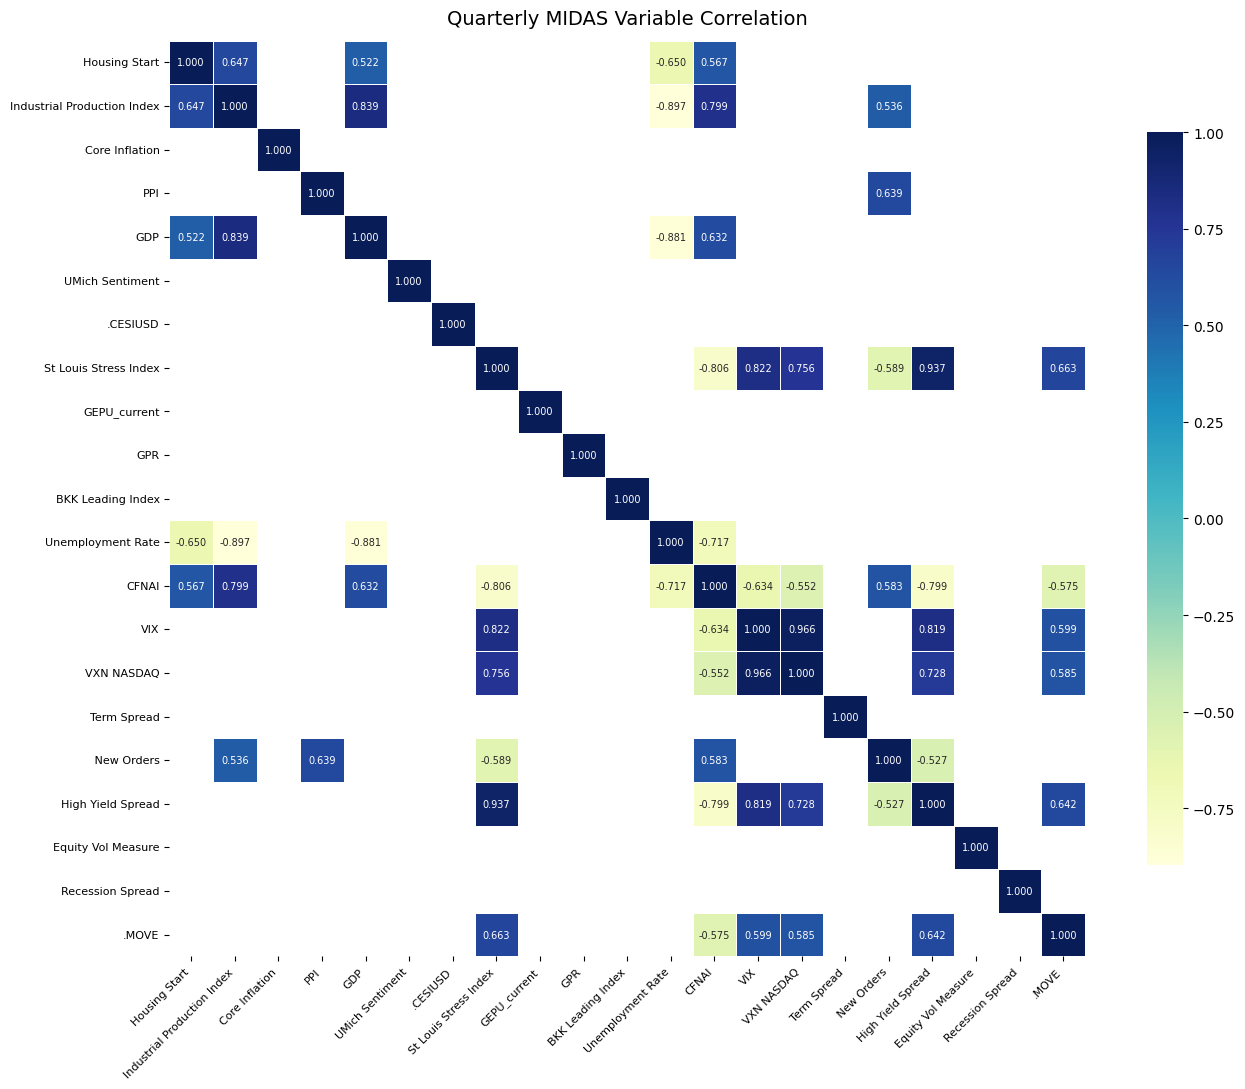

In [505]:
# Mask for pretty fades
mask = np.abs(Quarterly.corr()) < 0.50                

plt.figure(figsize=(14, 11))                   # make it larger
sns.heatmap(
    Quarterly.corr(),
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    annot_kws={"size": 7},                     # smaller annotation font
    mask=mask,                                 # fade weak correlations
    linewidths=.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Quarterly MIDAS Variable Correlation", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()


In [491]:
print(' Explained Variance :', PCA_.explained_variance_.round(4))
print(' Explained Variance Ratio (%) : ', PCA_.explained_variance_ratio_.round(4) * 100)

 Explained Variance : [6.9835 2.5089 1.916  1.7456 1.1886 1.1196 1.0565 0.9059 0.79   0.6211]
 Explained Variance Ratio (%) :  [32.84 11.8   9.01  8.21  5.59  5.27  4.97  4.26  3.72  2.92]


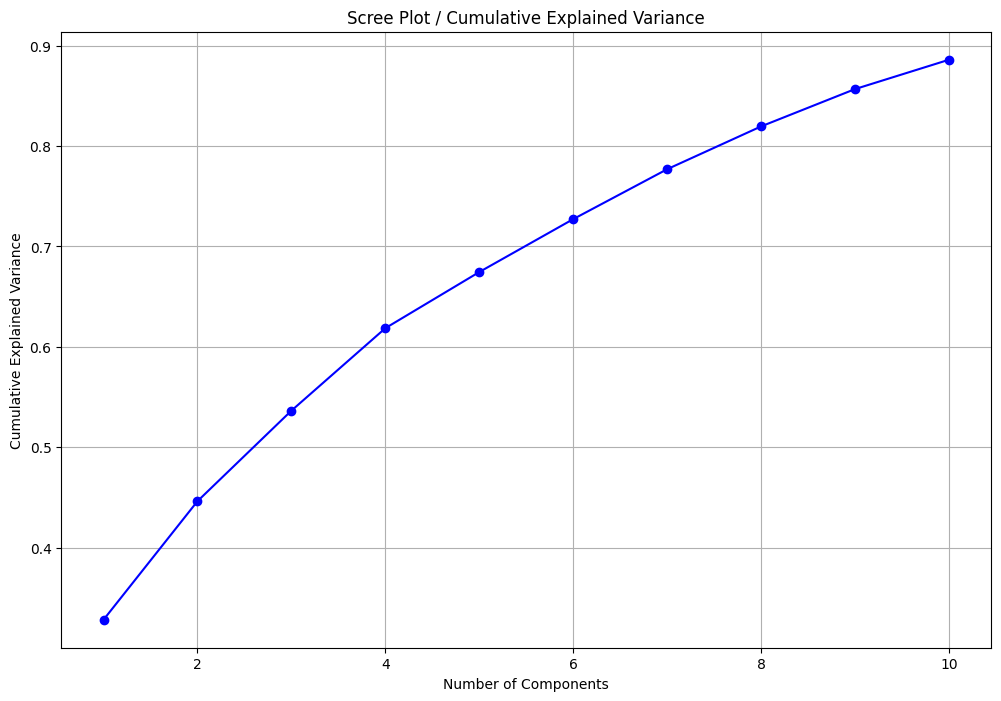

In [493]:
plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

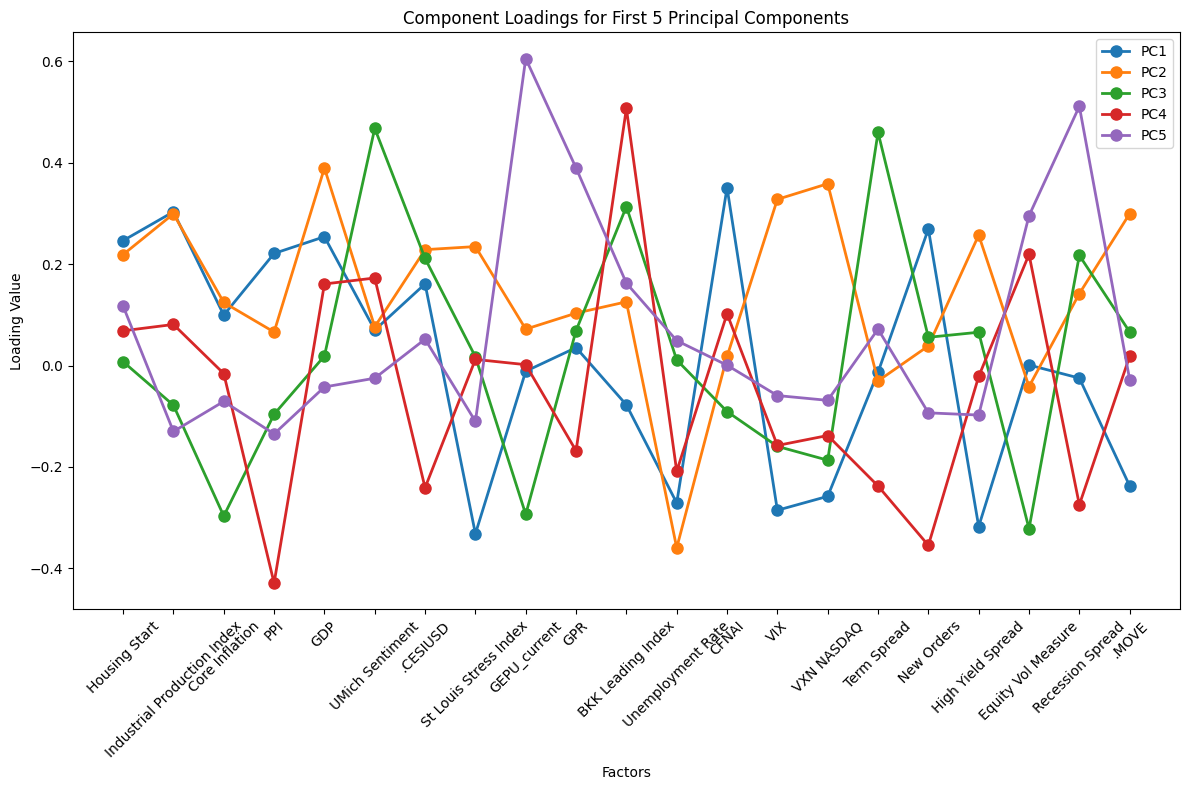

In [ ]:
#Change number of PCs to plot

# Get component loadings
loadings = pd.DataFrame(
    PCA_.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=Quarterly.columns
)

# Plot loadings for first n PCs on a single plot

PC_plot_n = 5 #Number of PCs to plot up to
plt.figure(figsize=(12, 8))
for i in range(n_components):
    if i < PC_plot_n:
        plt.plot(loadings.index, loadings[f'PC{i+1}'], 
             marker='o', 
             linewidth=2, 
             markersize=8,
             label=f'PC{i+1}')
    else:
        pass

plt.title(f'Component Loadings for First {PC_plot_n} Principal Components')
plt.xlabel('Factors')
plt.ylabel('Loading Value')
plt.grid(False)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## PCA on Monthly Data

We can see it takes almost 8 PCs to explain 80% of the variance. This shows our indicators chosen are capturing a lot of variance. 

We can use different numbers of PCs to identify which indices capture all PCs the best

In [224]:
n_components = 6
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Monthly)
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(X_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])


In [215]:
print(' Explained Variance :', PCA_.explained_variance_)
print(' Explained Variance Ratio :', PCA_.explained_variance_ratio_)

 Explained Variance : [4.83143137 2.22648503 1.98312056 1.40502689 1.04232807 0.98477704
 0.90627887 0.84078983 0.60278305 0.48627133]
 Explained Variance Ratio : [0.3007269  0.13858501 0.12343706 0.08745429 0.06487851 0.06129632
 0.05641029 0.052334   0.03751954 0.0302674 ]


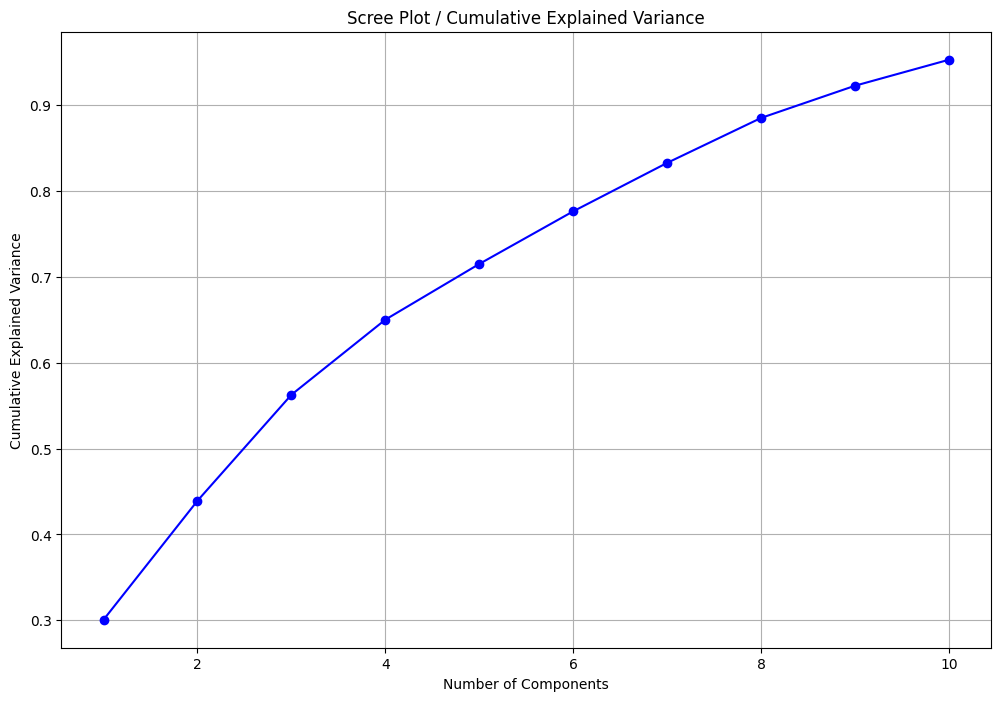

In [216]:
plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

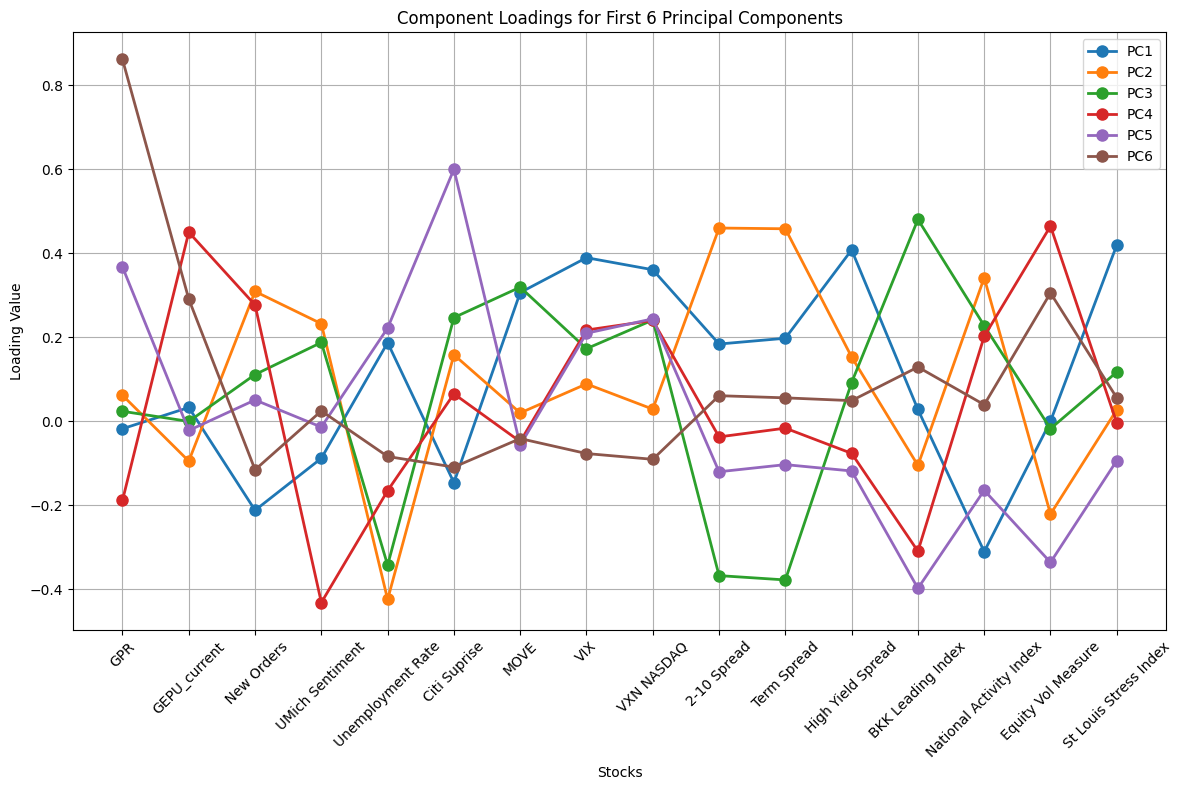

Top contributors to each principal component:


In [ ]:
#Change number of PCs to plot

# Get component loadings
loadings = pd.DataFrame(
    PCA_.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=Monthly.columns
)

# Plot loadings for first n PCs on a single plot
plt.figure(figsize=(12, 8))
for i in range(n_components):
    plt.plot(loadings.index, loadings[f'PC{i+1}'], 
             marker='o', 
             linewidth=2, 
             markersize=8,
             label=f'PC{i+1}')

plt.title(f'Component Loadings for First {n_components} Principal Components')
plt.xlabel('Stocks')
plt.ylabel('Loading Value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [229]:
Contributor_Score = {}


# Print top contributors for each PC
print("Top contributors to each principal component:")


for i in range(n_components):
    print(f"\nPC{i+1} (variance explained : {PCA_.explained_variance_ratio_[i].round(2)}):")
    top_contributors = loadings[f'PC{i+1}'].abs().sort_values(ascending=False).head(5)
    for stock, loading in top_contributors.items():
        print(f"{stock}: {loading:.3f}")
        if stock not in Contributor_Score.keys():
            Contributor_Score[stock] = loading * PCA_.explained_variance_ratio_[i]
        else:
            Contributor_Score[stock] = Contributor_Score[stock] + loading * PCA_.explained_variance_ratio_[i]
            


Top contributors to each principal component:

PC1 (variance explained : 0.3):
St Louis Stress Index: 0.420
High Yield Spread: 0.408
VIX: 0.390
VXN NASDAQ: 0.361
National Activity Index: 0.310

PC2 (variance explained : 0.14):
2-10 Spread: 0.460
Term Spread: 0.459
Unemployment Rate: 0.424
National Activity Index: 0.342
 New Orders: 0.309

PC3 (variance explained : 0.12):
BKK Leading Index: 0.481
Term Spread: 0.377
2-10 Spread: 0.367
Unemployment Rate: 0.342
MOVE: 0.320

PC4 (variance explained : 0.09):
Equity Vol Measure: 0.465
GEPU_current: 0.450
UMich Sentiment: 0.431
BKK Leading Index: 0.309
 New Orders: 0.277

PC5 (variance explained : 0.06):
Citi Suprise: 0.600
BKK Leading Index: 0.397
GPR: 0.368
Equity Vol Measure: 0.335
VXN NASDAQ: 0.244

PC6 (variance explained : 0.06):
GPR: 0.862
Equity Vol Measure: 0.306
GEPU_current: 0.291
BKK Leading Index: 0.130
 New Orders: 0.115


In [300]:
Economic_Monthly_Factors_PCA_Ranked = { i + 1 : sorted(Contributor_Score.items(), key=lambda x : -x[1])[i][0] for i in range(len(Contributor_Score.items()))}
Economic_Monthly_Factors_PCA_Ranked

{1: 'National Activity Index',
 2: 'St Louis Stress Index',
 3: 'VXN NASDAQ',
 4: 'High Yield Spread',
 5: 'BKK Leading Index',
 6: 'VIX',
 7: 'Term Spread',
 8: '2-10 Spread',
 9: 'Unemployment Rate',
 10: 'Equity Vol Measure',
 11: 'GPR',
 12: ' New Orders',
 13: 'GEPU_current',
 14: 'MOVE',
 15: 'Citi Suprise',
 16: 'UMich Sentiment'}